In [13]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [14]:
matchup_data = pd.read_csv("matchup_features.csv")

matchup_data.head()

,gameId,season_year,home_win,home_team,home_last_5_win_pct,home_offensive_average,home_defensive_average,home_last_5_point_diff,away_season_year,away_home_win,away_team,away_last_5_win_pct,away_offensive_average,away_defensive_average,away_last_5_point_diff,win_pct_diff,offense_diff,defense_diff,point_diff_diff
0,22000083,2021,0,Atlanta Hawks,NaN,NaN,NaN,NaN,2021,0,Cleveland Cavaliers,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,22000095,2021,0,Atlanta Hawks,NaN,NaN,NaN,NaN,2021,0,New York Knicks,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,22000110,2021,0,Atlanta Hawks,NaN,NaN,NaN,NaN,2021,0,Charlotte Hornets,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,22000153,2021,1,Atlanta Hawks,0.2,102.4,104.0,-1.6,2021,1,Philadelphia 76ers,0.6,119.6,117.2,2.4,-0.4,-17.2,-13.2,-4.0
4,22000205,2021,1,Atlanta Hawks,0.2,101.8,107.4,-5.6,2021,1,Minnesota Timberwolves,0.2,111.6,117.8,-6.2,0.0,-9.8,-10.4,0.6


In [23]:
feature_cols = [
    "win_pct_diff",
    "offense_diff",
    "defense_diff",
    "point_diff_diff"
]

model_df = matchup_data[
    feature_cols + ["home_win", "season_year"]
].dropna()
model_df.head()

,win_pct_diff,offense_diff,defense_diff,point_diff_diff,home_win,season_year
3,-0.4,-17.2,-13.2,-4.0,1,2021
4,0.0,-9.8,-10.4,0.6,1,2021
5,0.0,-0.2,1.6,-1.8,1,2021
6,-0.4,-8.4,10.6,-19.0,1,2021
7,0.2,-5.8,-13.2,7.4,0,2021


creating X and Y

In [25]:
X = matchup_data[feature_cols]

y = matchup_data["home_win"] # our target variable

In [26]:
train_df = model_df[model_df["season_year"] <= 2024].copy()
test_df = model_df[model_df["season_year"] == 2025].copy()

X_train = train_df[feature_cols]
y_train = train_df["home_win"]

X_test = test_df[feature_cols]
y_test = test_df["home_win"]

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (5736, 4)
Testing shape: (1387, 4)


5736 rows and 4 columns. in training data from 2021-2024. 1387 rows and 4 columns in test data from 2024-2025.

Now we will be trying different models.

Logistic regression

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

log_model = LogisticRegression()

log_model.fit(X_train, y_train)

preds = log_model.predict(X_test)

probs = log_model.predict_proba(X_test)[:, 1]

In [28]:
accuracy = accuracy_score(y_test, preds)

print("Accuracy:", accuracy)

print("Classification Report:")
print(classification_report(y_test, preds))

Accuracy: 0.6337418889689979
Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.45      0.53       630
           1       0.63      0.79      0.70       757

    accuracy                           0.63      1387
   macro avg       0.63      0.62      0.61      1387
weighted avg       0.63      0.63      0.62      1387



model correctly predicted 63.5% of the outcomes in the test set.so 878 games are good.  When the model predicts an away team win it is correct 64% of time and 63% of home wins.  This model captures only 0.45 the wins by an away team. so the model favors the home team predictions. so the home team with strong recent forms usually win. 

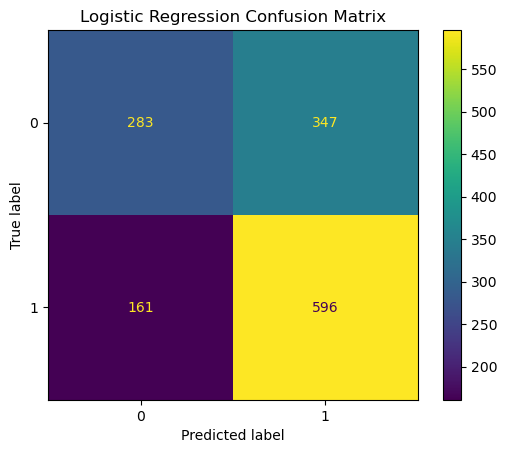

In [29]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")

plt.show()

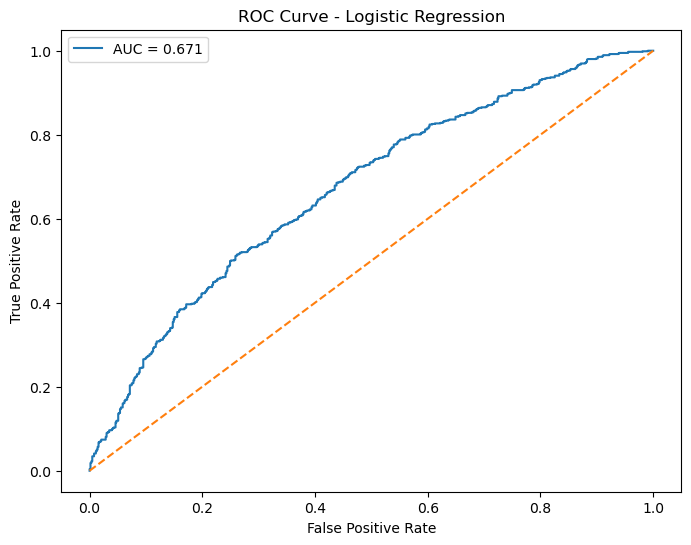

In [31]:
fpr, tpr, thresholds = roc_curve(y_test, probs)

auc_score = roc_auc_score(y_test, probs)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

Orange dashed line is random guessing and the blue lineis my model. AUC= 0.671 means meaningful predictive skills.

Feature Importance

In [32]:
coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": log_model.coef_[0]
})

coef_df = coef_df.sort_values(
    "Coefficient",
    ascending=False
)

coef_df

,Feature,Coefficient
0,win_pct_diff,0.081652
3,point_diff_diff,0.025844
1,offense_diff,0.013964
2,defense_diff,-0.011879


so momentum or the last 5 win pct for the home team is greater than for the away, they usally win.

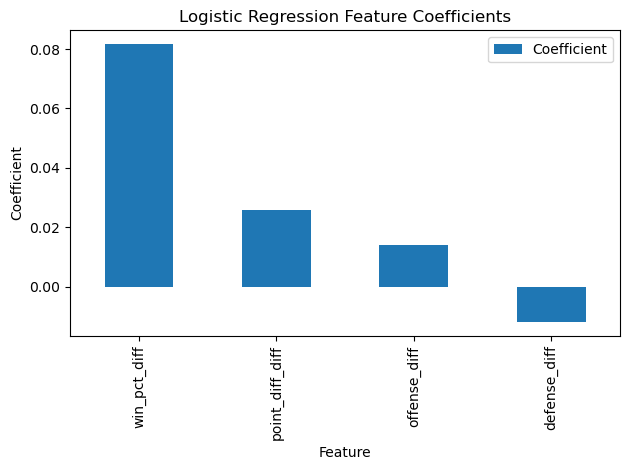

In [33]:
coef_df.plot(
    x="Feature",
    y="Coefficient",
    kind="bar"
)

plt.title("Logistic Regression Feature Coefficients")

plt.ylabel("Coefficient")

plt.tight_layout()

plt.show()

Ridge model

In [34]:
ridge_model = LogisticRegression(
    penalty="l2",
    C=1.0, # controls regularization strength
    max_iter=1000
)

ridge_model.fit(X_train, y_train)

c:\Users\Dell\miniforge3\envs\math4025\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [35]:
ridge_preds = ridge_model.predict(X_test)

ridge_probs = ridge_model.predict_proba(X_test)[:, 1]

ridge_accuracy = accuracy_score(
    y_test,
    ridge_preds
)

ridge_auc = roc_auc_score(
    y_test,
    ridge_probs
)

print("Ridge Accuracy:", ridge_accuracy)
print("Ridge ROC-AUC:", ridge_auc)


Ridge Accuracy: 0.6337418889689979
Ridge ROC-AUC: 0.6712975194481139


In [36]:
ridge_coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": ridge_model.coef_[0]
})

ridge_coef_df = ridge_coef_df.sort_values(
    "Coefficient",
    ascending=False
)

ridge_coef_df

,Feature,Coefficient
0,win_pct_diff,0.081652
3,point_diff_diff,0.025844
1,offense_diff,0.013964
2,defense_diff,-0.011879


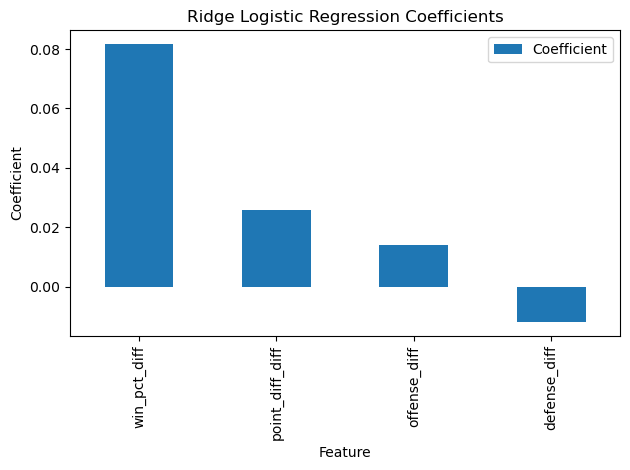

In [38]:
ridge_coef_df.plot(
    x="Feature",
    y="Coefficient",
    kind="bar"
)

plt.title("Ridge Logistic Regression Coefficients")

plt.ylabel("Coefficient")

plt.tight_layout()

plt.show()

good feature engineering. less overfitting.  but not much improvement in accuracy.

Lasso

In [39]:
lasso_model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=1.0,
    max_iter=1000
)

lasso_model.fit(X_train, y_train)

c:\Users\Dell\miniforge3\envs\math4025\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Dell\miniforge3\envs\math4025\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [41]:
lasso_preds = lasso_model.predict(X_test)

lasso_probs = lasso_model.predict_proba(X_test)[:, 1]
lasso_accuracy = accuracy_score(
    y_test,
    lasso_preds
)

lasso_auc = roc_auc_score(
    y_test,
    lasso_probs
)

print("Lasso Accuracy:", lasso_accuracy)
print("Lasso ROC-AUC:", lasso_auc)

Lasso Accuracy: 0.6330209084354722
Lasso ROC-AUC: 0.6713625212304208


In [42]:
lasso_coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": lasso_model.coef_[0]
})

lasso_coef_df = lasso_coef_df.sort_values(
    "Coefficient",
    ascending=False
)

lasso_coef_df

,Feature,Coefficient
0,win_pct_diff,0.064708
3,point_diff_diff,0.038166
1,offense_diff,0.002088
2,defense_diff,0.000000


model thinks offensive and defensive stats dont matter.

In [44]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    random_state=4025
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

rf_probs = rf_model.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(
    y_test,
    rf_preds
)

rf_auc = roc_auc_score(
    y_test,
    rf_probs
)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest ROC-AUC:", rf_auc)



Random Forest Accuracy: 0.6207642393655372
Random Forest ROC-AUC: 0.657158583380512


Feature importance

In [ ]:
rf_importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_model.feature_importances_
})

rf_importance_df = rf_importance_df.sort_values(
    "Importance",
    ascending=False
)

rf_importance_df



,Feature,Importance
3,point_diff_diff,0.487337
1,offense_diff,0.180115
2,defense_diff,0.173889
0,win_pct_diff,0.158659


teams that consistently blow out opponesnt are more likely to win. win pct diff is the lowest. it means that the model thinks that the win pct diff is not as important as the other features. so rf emphasized dominance, non linear and complex relationships.

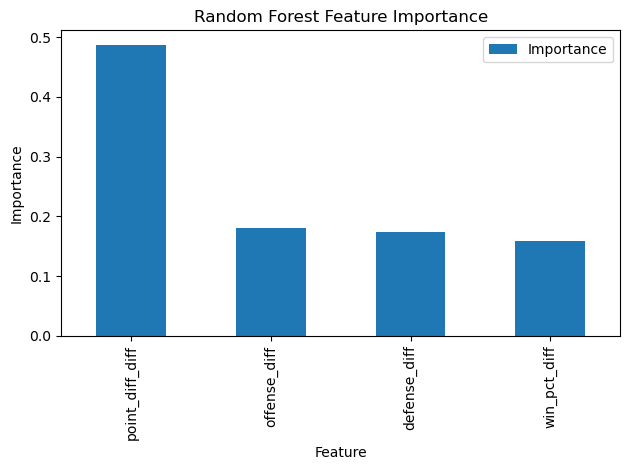

In [46]:
rf_importance_df.plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.title("Random Forest Feature Importance")

plt.ylabel("Importance")

plt.tight_layout()

plt.show()

XG boosting

In [ ]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=4025,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)



,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [51]:
xgb_preds = xgb_model.predict(X_test)

xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_accuracy = accuracy_score(
    y_test,
    xgb_preds
)

xgb_auc = roc_auc_score(
    y_test,
    xgb_probs
)

print("XGBoost Accuracy:", xgb_accuracy)
print("XGBoost ROC-AUC:", xgb_auc)

XGBoost Accuracy: 0.6099495313626532
XGBoost ROC-AUC: 0.6419775219643119


In [ ]:
xgb_importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": xgb_model.feature_importances_
})

xgb_importance_df = xgb_importance_df.sort_values(
    "Importance",
    ascending=False
)

xgb_importance_df


,Feature,Importance
3,point_diff_diff,0.375640
0,win_pct_diff,0.225758
2,defense_diff,0.204038
1,offense_diff,0.194564


point diff is the most important feature. it is a measure of how much a team wins or loses by. so teams that consistently blow out opponents are more likely to win. win pct diff is the lowest. it means that the model thinks that the win pct diff is not as important as the other features. so rf emphasized dominance, non linear and complex relationships. XG boost thinks recent momentum matters more than the RF model. 

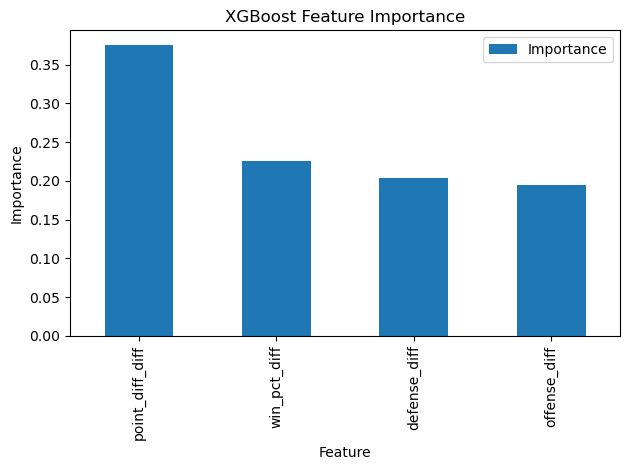

In [53]:
xgb_importance_df.plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.title("XGBoost Feature Importance")

plt.ylabel("Importance")

plt.tight_layout()

plt.show()

In [54]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Ridge",
        "Lasso",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy,
        ridge_accuracy,
        lasso_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],

    "ROC_AUC": [
        auc_score,
        ridge_auc,
        lasso_auc,
        rf_auc,
        xgb_auc
    ]
})

comparison_df

,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.633742,0.671298
1,Ridge,0.633742,0.671298
2,Lasso,0.633021,0.671363
3,Random Forest,0.620764,0.657159
4,XGBoost,0.609950,0.641978


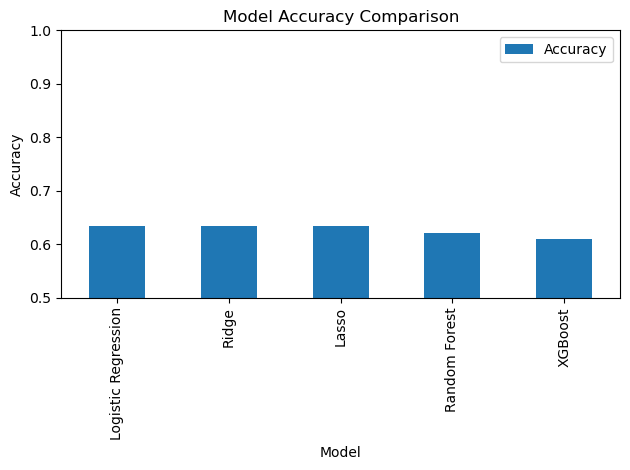

In [55]:
comparison_df.plot(
    x="Model",
    y="Accuracy",
    kind="bar"
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.ylim(0.5, 1.0)

plt.tight_layout()

plt.show()

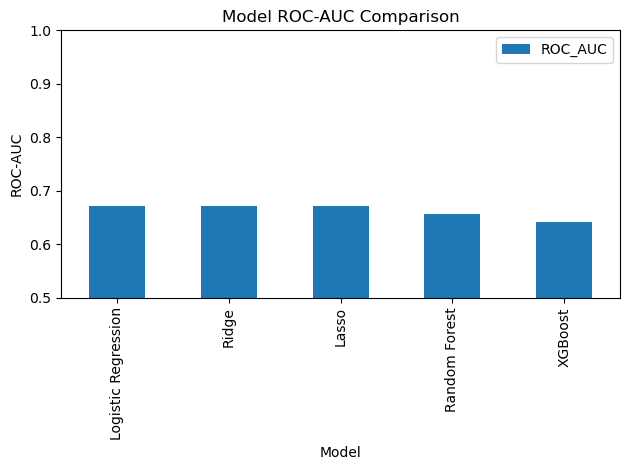

In [56]:
comparison_df.plot(
    x="Model",
    y="ROC_AUC",
    kind="bar"
)

plt.title("Model ROC-AUC Comparison")

plt.ylabel("ROC-AUC")

plt.ylim(0.5, 1.0)

plt.tight_layout()

plt.show()

In [64]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
xgb_param_grid = {

    "n_estimators": randint(100, 600),

    "max_depth": randint(2, 8),

    "learning_rate": uniform(0.01, 0.2),

    "subsample": uniform(0.6, 0.4),

    "colsample_bytree": uniform(0.6, 0.4),

    "min_child_weight": randint(1, 10)
}
xgb_base = XGBClassifier(
    random_state=4025,
    eval_metric="logloss"
)
xgb_search = RandomizedSearchCV(

    estimator=xgb_base,

    param_distributions=xgb_param_grid,

    n_iter=30,

    scoring="roc_auc",

    cv=5,

    verbose=1,

    n_jobs=-1,

    random_state=4025
)
xgb_search.fit(X_train, y_train)

print("Best Parameters:")
print(xgb_search.best_params_)

print("Best ROC-AUC:")
print(xgb_search.best_score_)

best_xgb = xgb_search.best_estimator_
best_xgb_preds = best_xgb.predict(X_test)

best_xgb_probs = best_xgb.predict_proba(X_test)[:, 1]



Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters:
{'colsample_bytree': np.float64(0.8702169181295794), 'learning_rate': np.float64(0.019737078726652126), 'max_depth': 2, 'min_child_weight': 9, 'n_estimators': 361, 'subsample': np.float64(0.7384000532152706)}
Best ROC-AUC:
0.6194777105643994


In [65]:
best_xgb_accuracy = accuracy_score(
    y_test,
    best_xgb_preds
)

best_xgb_auc = roc_auc_score(
    y_test,
    best_xgb_probs
)

print("Tuned XGBoost Accuracy:", best_xgb_accuracy)

print("Tuned XGBoost ROC-AUC:", best_xgb_auc)

Tuned XGBoost Accuracy: 0.6222062004325883
Tuned XGBoost ROC-AUC: 0.6565924388249356


logistic regression is the best model. it is the most interpretable and has the best performance. it is also the simplest model. so it is the best model for this problem.

In [67]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score


log_param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100]
}

# Base logistic regression model
log_base = LogisticRegression(
    max_iter=1000
)

# Grid search cross-validation
# Uses ROC-AUC as the scoring metric

log_search = GridSearchCV(
    
    estimator=log_base,
    
    param_grid=log_param_grid,
    
    scoring="roc_auc",
    
    cv=5,
    
    n_jobs=-1
)

# Fitting the grid search
log_search.fit(X_train, y_train)

# Printing best hyperparameters
print("Best Parameters:")
print(log_search.best_params_)

# Printing best cross-validation ROC-AUC
print("\nBest CV ROC-AUC:")
print(log_search.best_score_)

# Best tuned logistic regression model
best_log = log_search.best_estimator_

# Predictions on test set
best_log_preds = best_log.predict(X_test)

# Predicted probabilities for ROC-AUC
best_log_probs = best_log.predict_proba(X_test)[:, 1]

# Final evaluation metrics
best_log_accuracy = accuracy_score(
    y_test,
    best_log_preds
)

best_log_auc = roc_auc_score(
    y_test,
    best_log_probs
)

# Printing final tuned model performance
print("\nTuned Logistic Accuracy:")
print(best_log_accuracy)

print("\nTuned Logistic ROC-AUC:")
print(best_log_auc)

Best Parameters:
{'C': 0.001}

Best CV ROC-AUC:
0.6261571673155478

Tuned Logistic Accuracy:
0.631578947368421

Tuned Logistic ROC-AUC:
0.6714338135077897


| Model                          | Main Idea                          | Strengths                                | Weaknesses                            | Your Result                  |
| ------------------------------ | ---------------------------------- | ---------------------------------------- | ------------------------------------- | ---------------------------- |
| Logistic Regression (Baseline) | Linear matchup model               | Simple, interpretable, stable            | Cannot capture nonlinear interactions | Very strong                  |
| Ridge                          | Regularized logistic               | Reduces overfitting                      | Little improvement over baseline      | Nearly identical to baseline |
| Lasso                          | Sparse logistic model              | Feature selection                        | No major gain here                    | Similar to baseline          |
| Random Forest                  | Nonlinear tree ensemble            | Captures interactions                    | More variance, possible overfitting   | Good feature insights        |
| XGBoost                        | Boosted nonlinear trees            | Powerful complex learner                 | Did not generalize better here        | Slightly worse               |
| Tuned Logistic Regression      | Optimized regularized linear model | Best balance of simplicity + performance | Less flexible than trees              | BEST OVERALL                 |

so the baseline log model is still the best.  i would still use tuned logistic regression model tho.



In [68]:
comparison_df = pd.DataFrame({
    "Model": [
        "Baseline Logistic",
        "Ridge",
        "Lasso",
        "Random Forest",
        "XGBoost",
        "Tuned Logistic"
    ],

    "Accuracy": [
        accuracy,
        ridge_accuracy,
        lasso_accuracy,
        rf_accuracy,
        xgb_accuracy,
        best_log_accuracy
    ],

    "ROC_AUC": [
        auc_score,
        ridge_auc,
        lasso_auc,
        rf_auc,
        xgb_auc,
        best_log_auc
    ]
})

comparison_df

,Model,Accuracy,ROC_AUC
0,Baseline Logistic,0.633742,0.671298
1,Ridge,0.633742,0.671298
2,Lasso,0.633021,0.671363
3,Random Forest,0.620764,0.657159
4,XGBoost,0.609950,0.641978
5,Tuned Logistic,0.631579,0.671434


Accuracy plot

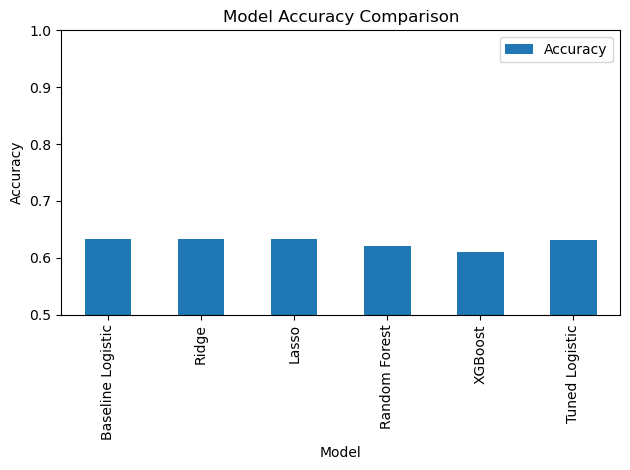

In [69]:
comparison_df.plot(
    x="Model",
    y="Accuracy",
    kind="bar"
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.ylim(0.5, 1.0)

plt.tight_layout()

plt.show()

roc-auc plot.

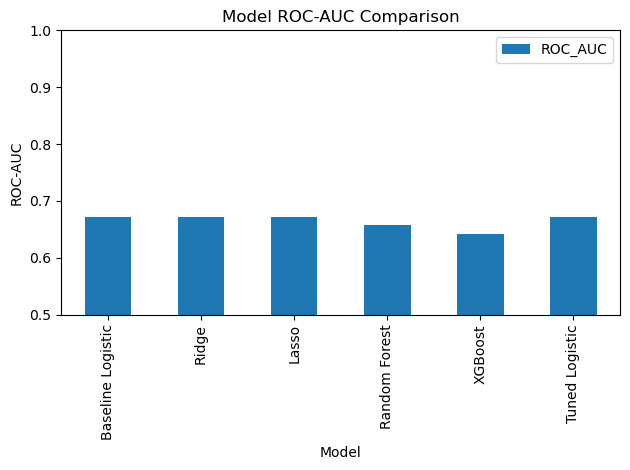

In [70]:
comparison_df.plot(
    x="Model",
    y="ROC_AUC",
    kind="bar"
)

plt.title("Model ROC-AUC Comparison")

plt.ylabel("ROC-AUC")

plt.ylim(0.5, 1.0)

plt.tight_layout()

plt.show()

the strongest possible model.

In [71]:
final_train_df = model_df[
    model_df["season_year"] <= 2025
].copy()

X_final = final_train_df[feature_cols]

y_final = final_train_df["home_win"]

final_model = LogisticRegression(
    C=0.001,
    max_iter=1000
)

final_model.fit(X_final, y_final)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.001
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`m

for predictcing future games . we willhave to just include the 2026 data.